Displaying SIFT Features...


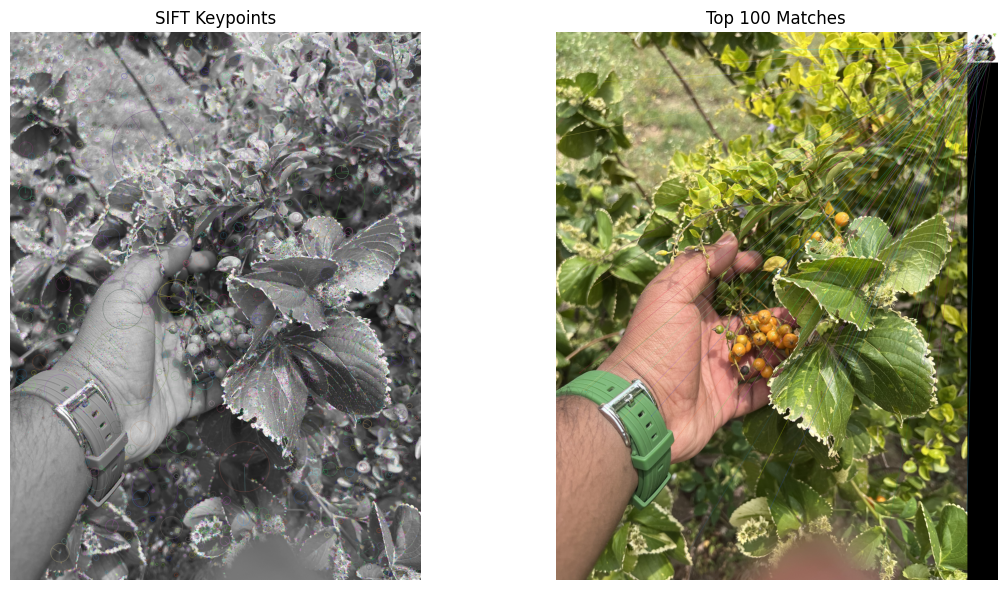

In [1]:
import cv2
import matplotlib.pyplot as plt

# --- Helper functions ---
def extract_sift_features(img):
    # Modern OpenCV uses cv2.SIFT_create()
    sift = cv2.SIFT_create()
    key_points, descriptors = sift.detectAndCompute(img, None)
    return key_points, descriptors

def show_sift_features(img_gray, img_color, key_points):
    # Draw keypoints on the image
    return cv2.drawKeypoints(img_gray, key_points, img_color.copy(),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# --- Main code ---
# Use absolute paths to avoid FileNotFoundError
image_path1 = r"C:\Users\venka\Downloads\Computer Vision lab\IMG_1626.jpg"
image_path2 = r"C:\Users\venka\Downloads\Computer Vision lab\images.jpg"

Image1 = cv2.imread(image_path1)
Image2 = cv2.imread(image_path2)

# Check if images loaded correctly
if Image1 is None:
    raise FileNotFoundError(f"Error: First image not found at {image_path1}")
if Image2 is None:
    raise FileNotFoundError(f"Error: Second image not found at {image_path2}")

# Convert to grayscale
Image1_gray = cv2.cvtColor(Image1, cv2.COLOR_BGR2GRAY)
Image2_gray = cv2.cvtColor(Image2, cv2.COLOR_BGR2GRAY)

# Extract SIFT features
Image1_key_points, Image1_descriptors = extract_sift_features(Image1_gray)
Image2_key_points, Image2_descriptors = extract_sift_features(Image2_gray)

print("Displaying SIFT Features...")
Image1_with_kp = show_sift_features(Image1_gray, Image1, Image1_key_points)

# Match descriptors
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(Image1_descriptors, Image2_descriptors)
matches = sorted(matches, key=lambda m: m.distance)

# Draw top 100 matches
matched_img = cv2.drawMatches(Image1, Image1_key_points,
                              Image2, Image2_key_points,
                              matches[:100], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(Image1_with_kp, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Top 100 Matches")
plt.axis("off")

plt.tight_layout()
plt.show()
